# 3. CTCF peaks vs domain boundaries

Здесь мы хотим проверить, связаны ли CTCF ChIP-seq peaks с границами доменов

**Входные файлы:**

- CTCF peaks из day3
- bedGraph для границ доменов, нужно вспомнить первый день и запустить блокнот 3.1_call_domain_boundaries.ipynb

**Библиотеки:** `pandas`, `numpy`, `matplotlib`, `seaborn`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyBigWig
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")

### Пути к файлам

Здесь берем:

- BED с границами доменов
- CTCF пики
- CTCF `bw` трек

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

boundaries_path = ROOT / "data/boundaries/MoPh7_boundaries.bed"
ctcf_peaks_path = ROOT / "../day3_ChIPseq_practice/results/macs/MoPh7_CTCF/MoPh7_CTCF_peaks.narrowPeak"
ctcf_bw_path = ROOT / "../day3_ChIPseq_practice/results/macs/MoPh7_CTCF/MoPh7_CTCF_FE.bw"

### Читаем границы и CTCF пики

In [3]:
boundaries = pd.read_csv(
    boundaries_path,
    sep="\t",
    header=None,
    names=["chrom", "start", "end", "name", "score"],
)
boundaries["center"] = ((boundaries["start"] + boundaries["end"]) / 2).astype(int)

ctcf = pd.read_csv(
    ctcf_peaks_path,
    sep="\t",
    header=None,
    usecols=[0, 1, 2, 4],
    names=["chrom", "start", "end", "score"],
)
ctcf["center"] = ((ctcf["start"] + ctcf["end"]) / 2).astype(int)

print("boundaries:", len(boundaries))
print("CTCF peaks:", len(ctcf))
boundaries.head()

boundaries: 4893
CTCF peaks: 49334


,chrom,start,end,name,score,center
0,chr1,740000,750000,boundary_0,0.697147,745000
1,chr1,1070000,1080000,boundary_1,1.097929,1075000
2,chr1,1360000,1370000,boundary_2,0.489446,1365000
3,chr1,1840000,1850000,boundary_3,0.473751,1845000
4,chr1,2170000,2180000,boundary_4,0.786446,2175000


### Пересечение границ с CTCF пики

Сначала посмотрим простой вопрос: у какой доли границ есть CTCF пик рядом.

In [5]:
BOUNDARY_WINDOW = 10_000

boundaries["window_start"] = (boundaries["center"] - BOUNDARY_WINDOW).clip(lower=0)
boundaries["window_end"] = boundaries["center"] + BOUNDARY_WINDOW

has_ctcf = []

for row in boundaries.itertuples(index=False):
    ctcf_chr = ctcf[ctcf["chrom"] == row.chrom]
    hit = (
        (ctcf_chr["end"] > row.window_start)
        & (ctcf_chr["start"] < row.window_end)
    ).any()
    has_ctcf.append(hit)

boundaries["has_ctcf_peak"] = has_ctcf

print(
    f"Borders with CTCF peak ±{BOUNDARY_WINDOW // 1000} kb:",
    f"{boundaries['has_ctcf_peak'].sum()}/{len(boundaries)}",
    f"({boundaries['has_ctcf_peak'].mean():.1%})",
)

Borders with CTCF peak ±10 kb: 2451/4893 (50.1%)


### CTCF сигнал вокруг границ

Берем CTCF `bw` и строим средний профиль сигнала вокруг центров границ

Контроль: случайные центры на тех же хромосомах, столько же точек на каждую хромосому

In [12]:
flank = 300_000
bin_size = 10_000
n_bootstrap = 5
random_seed = 42

offsets = np.arange(-flank, flank + bin_size, bin_size)
offsets_mb = offsets / 1_000_000

rng = np.random.default_rng(random_seed)

In [13]:
def centers_by_chrom(table):
    return {
        chrom: part["center"].to_numpy(dtype=int)
        for chrom, part in table.groupby("chrom")
    }


def average_bw_profile(bw_path, centers):
    profile = np.full(len(offsets), np.nan)
    support = np.zeros(len(offsets), dtype=int)

    with pyBigWig.open(str(bw_path)) as bw:
        chrom_sizes = bw.chroms()

        for i, offset in enumerate(offsets):
            values = []

            for chrom, centers_array in centers.items():
                if chrom not in chrom_sizes:
                    continue

                starts = centers_array + offset
                ends = starts + bin_size

                valid = (starts >= 0) & (ends <= chrom_sizes[chrom])
                starts = starts[valid]
                ends = ends[valid]

                for start, end in zip(starts, ends):
                    value = bw.stats(chrom, int(start), int(end), type="mean")[0]
                    if value is not None and not np.isnan(value):
                        values.append(value)

            if values:
                profile[i] = np.mean(values)
                support[i] = len(values)

    return profile, support

In [14]:
real_centers = centers_by_chrom(boundaries)
real_profile, real_support = average_bw_profile(ctcf_bw_path, real_centers)

In [15]:
def make_random_boundaries_like_real(boundaries):
    random_rows = []

    with pyBigWig.open(str(ctcf_bw_path)) as bw:
        chrom_sizes = bw.chroms()

    for chrom, part in boundaries.groupby("chrom"):
        if chrom not in chrom_sizes:
            continue

        n = len(part)
        low = flank
        high = chrom_sizes[chrom] - flank

        if high <= low:
            continue

        random_centers = rng.integers(low, high, size=n)

        random_rows.append(pd.DataFrame({
            "chrom": chrom,
            "center": random_centers,
        }))

    return pd.concat(random_rows, ignore_index=True)


control_profiles = []

for i in range(n_bootstrap):
    random_boundaries = make_random_boundaries_like_real(boundaries)
    random_profile, _ = average_bw_profile(ctcf_bw_path, centers_by_chrom(random_boundaries))
    control_profiles.append(random_profile)
    print(f"control {i + 1}/{n_bootstrap} done")

control_profiles = np.vstack(control_profiles)
control_mean = np.nanmean(control_profiles, axis=0)
control_std = np.nanstd(control_profiles, axis=0)

control 1/5 done
control 2/5 done
control 3/5 done
control 4/5 done
control 5/5 done


### График обогащения CTCF на границах

Если CTCF связан с границами доменов, зеленая линия должна быть выше контроля около нуля

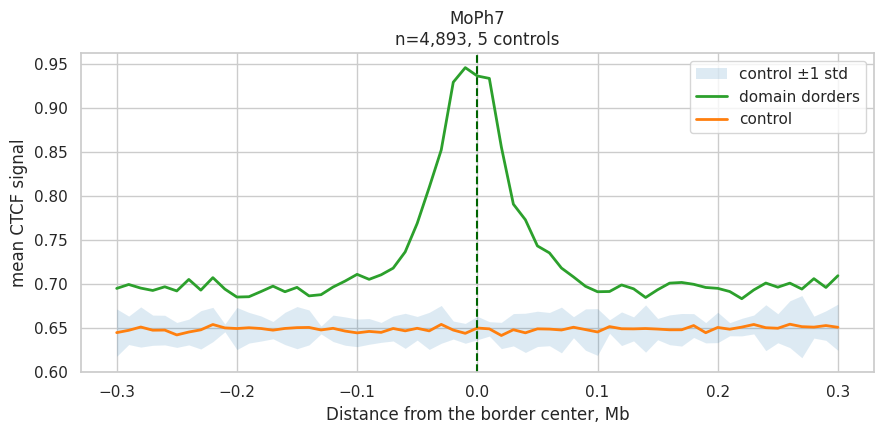

In [17]:
plt.figure(figsize=(9, 4.5))

plt.fill_between(
    offsets_mb,
    control_mean - 3 * control_std,
    control_mean + 3 * control_std,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
    label="control ±1 std",
)

plt.plot(
    offsets_mb,
    real_profile,
    color="tab:green",
    linewidth=2,
    label="domain dorders",
)

plt.plot(
    offsets_mb,
    control_mean,
    color="tab:orange",
    linewidth=2,
    label="control",
)

plt.axvline(0, color="darkgreen", linestyle="--", linewidth=1.5)
plt.xlabel("Distance from the border center, Mb")
plt.ylabel("mean CTCF signal")
plt.title(f"MoPh7\n"
          f"n={len(boundaries):,}, {n_bootstrap} controls")
plt.legend()
plt.tight_layout()
plt.show()

ВЫВОД: CTCF часто связан с границами доменов, но не каждая граница обязана иметь CTCF пик и наоборот